In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [41]:
def three_body_rhs(t, y, m, G=1.0, eps=1e-2):
    # Unpack
    r = y[:6].reshape(3, 2)   # positions
    v = y[6:].reshape(3, 2)   # velocities
    
    a = np.zeros_like(r)
    
    # Compute accelerations
    for i in range(3):
        for j in range(3):
            if i == j:
                continue
            diff = r[j] - r[i]
            dist2 = diff @ diff + eps**2
            inv_dist3 = dist2 ** (-1.5)
            a[i] += G * m[j] * diff * inv_dist3
    
    # Pack derivatives: dr/dt = v, dv/dt = a
    dydt = np.concatenate([v.reshape(-1), a.reshape(-1)])
    return dydt

In [42]:
m = np.array([1.0, 1.0, 1.0])  # masses

r0 = np.array([
    [-1.0,  0.1],
    [ 1.0,  0.0],
    [ 0.0,  0.5]
])

v0 = np.array([
    [ 0.0,  0.35],
    [ 0.0, -0.35],
    [ 0.4,  0.0]
])

y0 = np.concatenate([r0.reshape(-1), v0.reshape(-1)])

In [43]:
t_span = (0.0, 60.0)
t_eval = np.linspace(*t_span, 6000)

sol = solve_ivp(
    fun=lambda t, y: three_body_rhs(t, y, m, G=1.0, eps=1e-2),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9,
    method="DOP853"
)

sol.success, sol.message

(True, 'The solver successfully reached the end of the integration interval.')

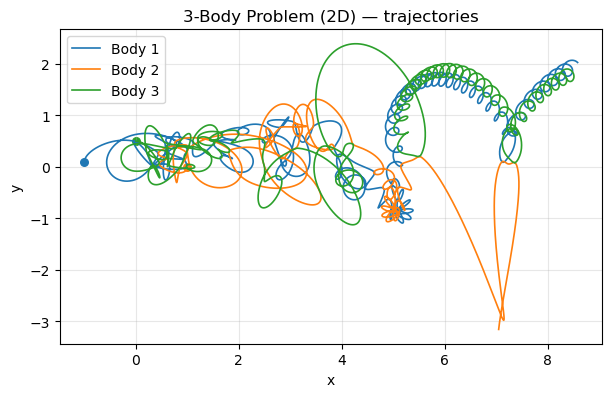

In [44]:
r = sol.y[:6].reshape(3, 2, -1)

plt.figure(figsize=(7,7))
for i in range(3):
    plt.plot(r[i,0], r[i,1], linewidth=1.2, label=f"Body {i+1}")
    plt.scatter(r[i,0,0], r[i,1,0], s=30)  # start point

plt.gca().set_aspect("equal", "box")
plt.title("3-Body Problem (2D) — trajectories")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()